# Data-driven approximation of the phase of neuron models 

## Hindmarsh-Rose model

In this notebook, we provide the numerics to illustrate the phase-amplitude framework. We will integrate a 2-dimensional version of the Hindmarch-Rose model, 
\begin{equation}
\begin{aligned}
\dot x = c \Big(x - \frac{x^3}{3} - y + I\Big), \\
\dot y= \frac{x^2+dx-by+a}{c},
\end{aligned}
\end{equation}
tuned to a SNIC bifurcation, corresponding to type I excitability.

Folloiwng Xie et al. PRE 2008, we set $a=0.42$, $b = 1.0$, $c = 3.0$ and $d= 1.8$, such that a SNIC bifurcation occurs at $I = 0.3463$ (and a subcritical Hopf at $I = 2.3420)$.

In [1]:
# Necessary packages
#import sys
#!{sys.executable} -m pip install matplotlib
#!{sys.executable} -m pip install scikit-learn
#!{sys.executable} -m pip install tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.cluster import KMeans
import time
from tqdm import tqdm
import warnings

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define functions for integrating the system 
def f(x, y, a, b, c, d, I):
    """Return (fx, fy) for the given state."""
    fx = c*(x - x**3 / 3 - y + I)
    fy = (x**2 +d*x - b*y + a)/c
    return fx, fy

def HR(X0, P, nSteps, dt):
    """
    Run the dynamics of a Hindmarsh-Rose neuron.

    Parameters
    ----------
    X0 : array-like
        Initial conditions, [x, y].
    P : tuple
        Deterministic parameters + noise amplitudes: (a, b, c, d, I, Dx, Dy).
    nSteps : int
        Number of integration steps.
    dt : float
        Timestep.

    Returns
    -------
    Xs : np.ndarray, shape (2, nSteps)
        Trajectory of [x, y] over time.
    """
    a, b, c, d, I, Dx, Dy = P

    Xs = np.empty((2, nSteps))
    Xs[:, 0] = np.copy(X0)

    x, y = X0
    dW = np.sqrt(dt) * np.random.randn(nSteps, 2)

    for i in range(1, nSteps):
        fx, fy = f(x, y, a, b, c, d, I)
        
        # Update
        x += fx * dt + np.sqrt(Dx) * dW[i, 0]
        y += fy * dt + np.sqrt(Dy) * dW[i, 1]

        Xs[0, i] = x; Xs[1, i] = y

    return Xs

We can put the neuron in a regime of parameters such that there are limit-cycle oscillations. Noise will then act as a perturbation leading to irregularities in the oscillations. We can look at the state space and at the actual trajectories of the system.

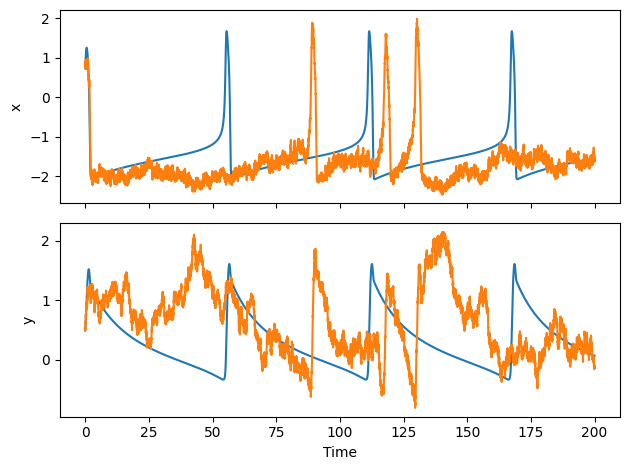

In [4]:
# Parameters
a, b, c, d, I, Dx, Dy = 0.42, 1.0, 3.0, 1.8, 0.4, 0.1, 0.05
PDet = (a, b, c, d, I, 0, 0)
PSto = (a, b, c, d, I, Dx, Dy)

# ICs
X0 = np.random.rand(2)

# Integration parameters
t_target = 200
dt = 1e-2
nSteps = int(t_target/dt)
ts = np.linspace(0, t_target, nSteps)

# Run
XsDet = HR(X0, PDet, nSteps, dt)
XsSto = HR(X0, PSto, nSteps, dt)

# Plot and compare
fig, axs = plt.subplots(2, sharex=True)

axs[0].plot(ts, XsDet[0,:])
axs[0].plot(ts, XsSto[0,:])
axs[0].set_ylabel('x')

axs[1].plot(ts, XsDet[1,:])
axs[1].plot(ts, XsSto[1,:])
axs[1].set_ylabel('y')

axs[1].set_xlabel('Time')
plt.tight_layout()
plt.show()

The data still is oscillatory, but strongly perturbed by the noise, such that there is no clear period $T$ anymore: $\mathbf x(t+T) \neq \mathbf x(t)$.

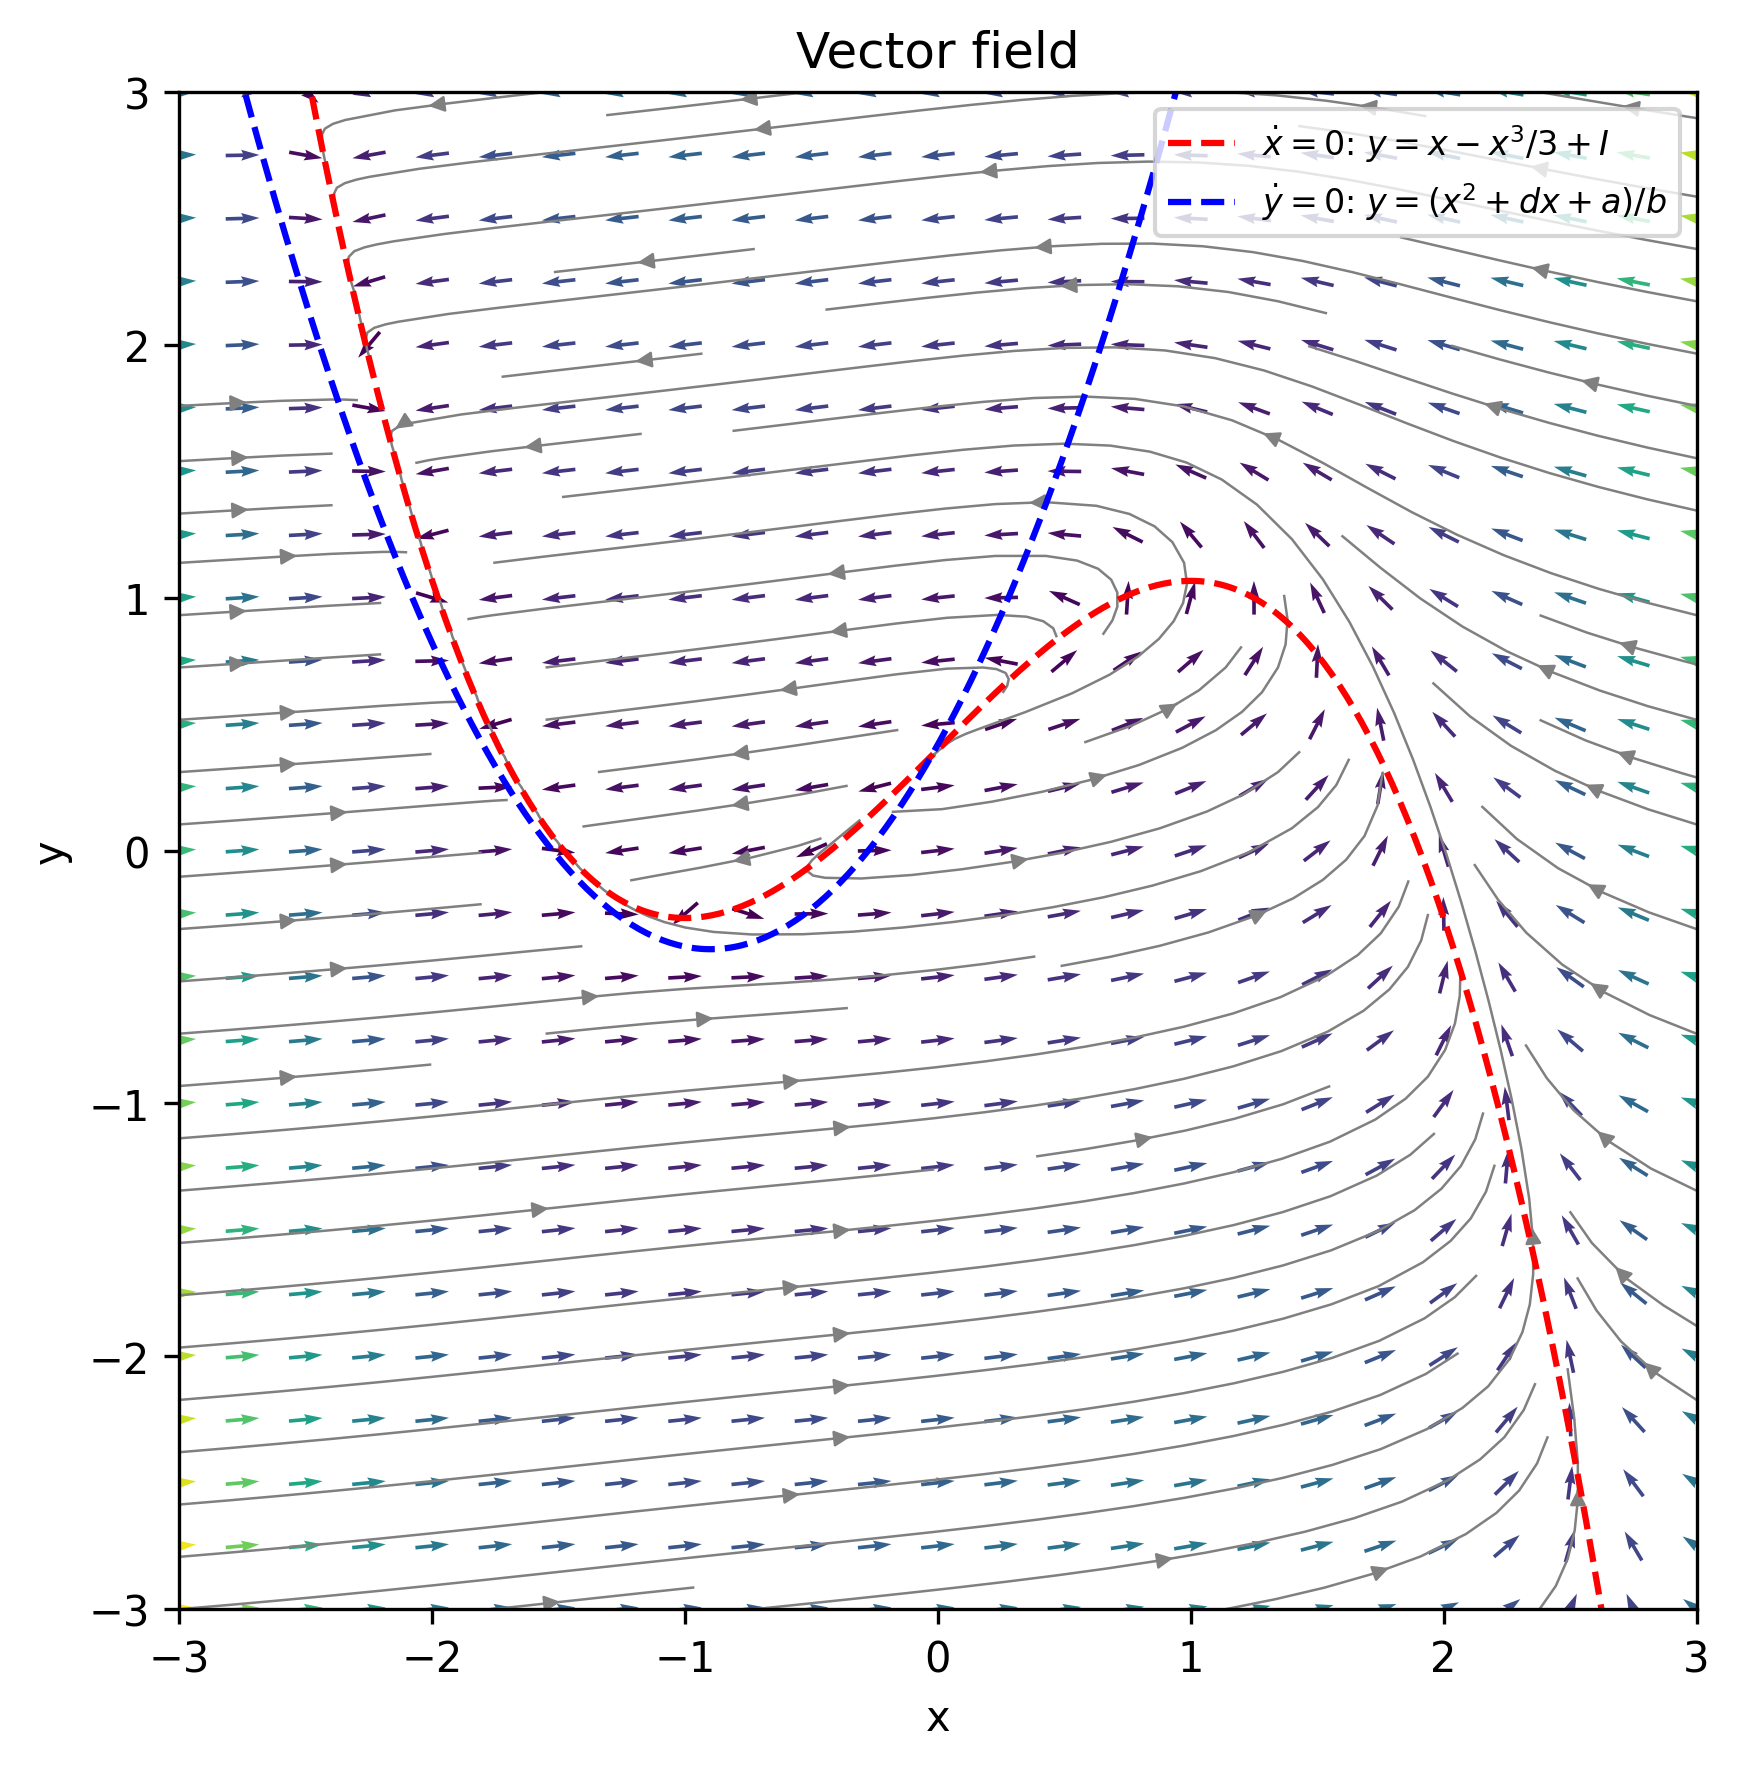

In [6]:
def plot_vector_field(a , b , c, d, I, x_min = -3, x_max = 3, y_min = -3, y_max = 3, n_points = 25, n_points_stream = 300):
    """
    # 
    x_min, x_max, y_min, y_max:
        Domain over which to plot the field
        floats, default -3, 3
    n_points: 
        grid resolution for the quiver arrows
        int, default 25
    n_points_stream:
        grid resolution for streamlines (finer looks nicer)
        int, default 300   
    """

    # Plot in state space
    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

    # ---- Quiver (arrows) ----
    x = np.linspace(x_min, x_max, n_points)
    y = np.linspace(y_min, y_max, n_points)
    X, Y = np.meshgrid(x, y)
    FX, FY = f(X, Y, a , b , c, d, I)
    
    # Normalize arrow lengths for a cleaner look, but keep color = magnitude
    mag = np.sqrt(FX**2 + FY**2)
    mag[mag == 0] = 1e-12  # avoid divide-by-zero
    FX_n, FY_n = FX / mag, FY / mag
    
    q = ax.quiver(X, Y, FX_n, FY_n, mag, cmap="viridis", pivot="mid")
    #fig.colorbar(q, ax=ax, label="|F(x, y)|")
    
    # ---- Streamlines (finer grid, gives smooth flow lines) ----
    xs = np.linspace(x_min, x_max, n_points_stream)
    ys = np.linspace(y_min, y_max, n_points_stream)
    Xs, Ys = np.meshgrid(xs, ys)
    FXs, FYs = f(Xs, Ys, a , b , c, d, I)
    ax.streamplot(Xs, Ys, FXs, FYs, color="gray", density=1.0,
                   linewidth=0.6, arrowsize=0.8)
    
    # ---- Nullclines ----
    # fx = 0  ->  y = x - x^3/3 + I
    xn = np.linspace(x_min, x_max, 400)
    ax.plot(xn, xn - xn**3 / 3 + I, "r--", label=r"$\dot{x}=0$: $y = x - x^3/3 + I$")
    # fy = 0  ->  y = (x^2 + dx + a) / b
    ax.plot(xn, (xn**2 + d*xn + a) / b, "b--", label=r"$\dot{y}=0$: $y = (x^2 + dx + a) / b$")

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Vector field")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_aspect("equal")
    
    plt.tight_layout()
    #plt.savefig("vector_field.png", dpi=150)
    plt.show()

    return

plot_vector_field(a , b , c, d, I)
    

We will now apply our operator based analysis of our system using Extended Dynamic Mode Decomposition (EDMD). For this, we need to define a basis of functions on which to approximate the Koopman operator. We will use radial basis functions (RBFs)

$F_j(\mathbf x) = ||\mathbf x - \mathbf c_j ||^2 \ln \Big(||\mathbf x - \mathbf c_j || + \epsilon_j\Big),$

which have nice properties thanks to the kernel trick. RBFs need centers $\mathbf c_i$, that we are going to define from our data using the k-means algorithm (similarly to what was done in Williams et al. (J Nonlinear Sci 2015), we apply the k-means to a long realization of the system).

In [7]:
def build_F_RBFs(centers):
    """
    centers : (N_c, 2)
    returns : function F(X) -> (N_c, N)
    """
    N_centers, _ = centers.shape
    epsilons = 1e-4 * np.ones(N_centers)

    def F(X):
        """
        X : (2, N)
        returns : (N_c, N)
        """
        diff = X[None, :, :] - centers[:, :, None]   # (N_c, 2, N)
        r2   = np.sum(diff**2, axis=1)                # (N_c, N)
        r    = np.sqrt(r2)                             # (N_c, N)
        return r2 * np.log(r + epsilons[:, None])      # (N_c, N)

    return F

def find_centers(Xs, N_centers, plot=True):
    # Ensure (n_samples, n_features) orientation
    if Xs.shape[0] < Xs.shape[1]:
        Xs = Xs.T                          # now (20000, 2)

    Xs = np.array(Xs, dtype=np.float64)   # force float64 — prevents overflow in matmul
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning) # Ignore annoying warnings
        kmeans = KMeans(n_clusters=N_centers, random_state=0, n_init='auto')
        kmeans.fit(Xs)

    centers = kmeans.cluster_centers_
    labels  = kmeans.labels_

    if plot:
        fig, ax = plt.subplots(figsize=(7, 5))

        ax.scatter(Xs[:, 0], Xs[:, 1],
                   c=labels, cmap='tab20',
                   s=2, alpha=0.4, linewidths=0)

        ax.scatter(centers[:, 0], centers[:, 1],
                   c='black', marker='x', s=80, linewidths=2,
                   zorder=5, label='Centers')

        for i, (cx, cy) in enumerate(centers):
            ax.annotate(str(i), (cx, cy),
                        textcoords='offset points', xytext=(6, 4),
                        fontsize=7, color='black')

        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title(f'{N_centers} k-means centers')
        ax.legend(markerscale=1.5)
        plt.tight_layout()
        plt.show()

    return centers   # (N_centers, 2)

We will also use those recovered functions to make predictions about the behaviour of the system: notably, we expect the average of the phase gradient on a given isochrone to give the average phase response of the system to an external, instaneous pulse. To make things easier, we will compute that average from a long realization of the system: we will bin the phase gradient values by the corresponding phase value and compute the mean of each bin such that

$iPRC(\psi) = \langle \boldsymbol \nabla \Psi(\mathbf x) \rangle_{\Psi(\mathbf x) = \psi}$.

This means we will need the derivatives of each $F_j$ to compute the PRC. They write:

$\partial_x F_j(\mathbf x) = \big[ 2 \ln (r+\epsilon_j) + \frac{r}{r+\epsilon_j}\big](x - (c_j)_x)$ 

with 

$r = \sqrt{x^2 + y^2}$. We define them now for simplicity:

In [8]:
def build_dF_RBFs(centers):
    """
    centers  : (N_c, 2)        - k-means centers
    returns  : function dF(X) -> (N_c, 2, N)
    """
    N_centers, _ = centers.shape
    epsilons = 1e-4 * np.ones(N_centers)

    def dF(X):
        """
        X : (2, N)          - trajectory points
        returns : (N_c, 2, N) - gradient w.r.t. x (both components)
        """
        diff = X[None, :, :] - centers[:, :, None]   # (N_c, 2, N)
        r2   = np.sum(diff**2, axis=1)                # (N_c, N)
        r    = np.sqrt(r2)                             # (N_c, N)
        # Scalar prefactor: 2*ln(r+eps) + r/(r+eps)
        re     = r + epsilons[:, None]                 # (N_c, N)
        factor = 2 * np.log(re) + r / re               # (N_c, N)
        # Multiply each spatial component of diff by the scalar factor
        return factor[:, None, :] * diff               # (N_c, 2, N)

    return dF

Now that we have all the ingredients, we can define the EDMD algorithm itself, as well as the functions that allow to recover the relevant eigenvalues and eigenfunctions from the spectrum.

In [12]:
def EDMD(FX, FY, tauSmpl):
    """
    FX: array containing the data points at t
    FY: array containing the data points at t + tauSmpl
    """

    # Diagonalize
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning) # Ignore annoying warnings
        # Construct best approx matrix
        K = np.linalg.pinv(FX @ FX.T) @ FX @ FY.T
        evals, evecs = np.linalg.eig(K)
    
    # Continuous eigenvalues
    lambdas = np.log(evals)/tauSmpl

    return lambdas, evecs

def find_lambda_1(evals, imThr=1e-8):
    # Find robustly oscillatory eigenvalue in a list of eigenvalues
    minRe = 1e10
    lambda_1 = None
    index1 = None  # Ensure index1 is always defined

    for i in range(len(evals)):
        im = np.imag(evals[i])
        re = np.real(evals[i])
        # Non-purely real, slowest rotating, slowest decaying
        if im > imThr and abs(re) <= minRe and re <= 0:
            index1 = i
            minRe = abs(re)
            lambda_1 = evals[i]

    return lambda_1, index1

def find_lambda_Floquet(eigenVals):
    eigenVals = np.array(eigenVals)
    re = np.real(eigenVals)
    im = np.imag(eigenVals)

    # Purely real mask: imaginary part negligible
    mask = (np.abs(im) < 1e-6) & (re < -1e-2)  # raised from -1e-4 to -1e-2

    if not np.any(mask):
        return None, None

    # Find least negative (closest to 0 from below)
    candidates = np.where(mask)[0]
    idx = candidates[np.argmax(re[candidates])]
    return re[idx], idx
    
def select(lambdas, evecs):
    #Find vector corresponding to phase efunc
    lambda_1, index1 = find_lambda_1(lambdas)
    q1 = evecs[:,index1]
    
    #Find vector corresponding to amplitude efunc
    lambdaFloquet, indexFloquet = find_lambda_Floquet(lambdas)
    qSigma = evecs[:,indexFloquet]

    print(lambda_1, lambdaFloquet)
    
    # Plot: keep the few less negative ones
    lambdastoPlot = np.sort(lambdas)[-50:]
    plt.axhline(0, c='k')
    plt.axvline(0, c='k')
    plt.plot(lambdastoPlot.real, lambdastoPlot.imag, "ko")
    plt.plot(lambda_1.real, lambda_1.imag, "r*", label = "Dominant oscillatory mode")
    plt.plot(lambdaFloquet.real, lambdaFloquet.imag, "b*", label = "Amplitude mode")
    plt.title('Recovered Ruelle-Pollicott resonances')
    plt.xlabel(r'$R [\lambda]$')
    plt.ylabel(r'$Im [\lambda]$')
    plt.legend()
    plt.show()
    
    return q1, qSigma.real

Main step: 

    - generate a long time series of the Hindmarsh-Rose
    - lift it into monomial space
    - Separate between FX and FY
    - apply EDMD
    - save the results so we don't need to rerun

In [10]:
def runEDMD(P, func, nTarget, tauTarget):
    # Run EDMD on full data once, store relevant functions to reuse later
    # The goal is 1e6 datapoints with sampling time = 1e-1
    X0 = np.random.rand(2)
    dt = 1e-2
    subSmplRate = int(tauTarget/dt)
    nSteps = int(nTarget*subSmplRate)
    
    start = time.time()
    
    # Generate data and subsample
    print("Generating data")
    Xs = HR(X0, P, nSteps, dt)
    Xs = Xs[:,::subSmplRate]
    F = func(Xs)
    
    # Split between t and t+tau
    FX = F[:,:-1]
    FY = F[:,1:]
    
    # Apply EDMD and return the relevant eigenvectors for our eigenfunctions
    print("Running EDMD")
    lambdas, evecs = EDMD(FX, FY, tauTarget)
    print("Done")
    elapsed = time.time() - start
    
    print(f"Runtime: {elapsed:.2f}s ({elapsed/60:.2f} min)")

    return lambdas, evecs, centers

Finding centers (may take some time)
Generating data
Running EDMD
Done
Runtime: 390.83s (6.51 min)
(-0.18051659639250306+0.1843081033479994j) -0.4508726912815262


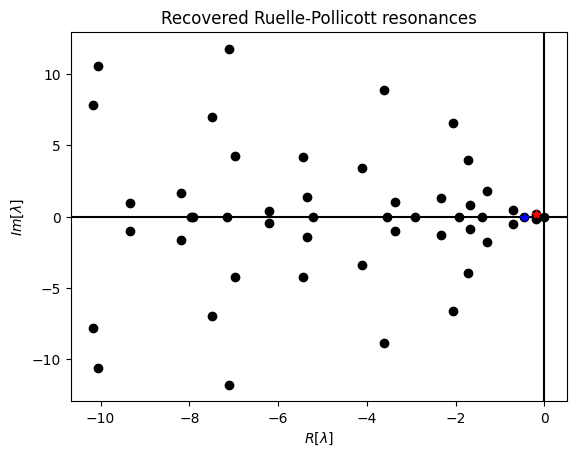

Saved EDMD functions to ./HR_RBF_func.npz


In [11]:
# SKIP THIS CELL IF YOU ALREADY HAVE THE DATA PRODUCED - GO TO THE CELL BELOW

# Integration parameters
t_target = 30
dt = 1e-2
nSteps = int(t_target/dt)
Xs = HR(X0, PSto, nSteps, dt)

# find centers for EDMD basis
print("Finding centers (may take some time)")
N_centers = 1000
centers = find_centers(Xs, N_centers, plot=False)
fRBF = build_F_RBFs(centers)

# How many data points + time step
nTarget = 1e6
tauTarget = 1e-1

# Main
lambdas, evecs, centers = runEDMD(PSto, fRBF, nTarget, tauTarget)
q1, qSigma = select(lambdas, evecs)

# Save the function ingredients 
save_path = './HR_RBF_func.npz'
np.savez(save_path,
         centers=centers,
         lambdas=lambdas,
         evecs=evecs)

print(f"Saved EDMD functions to {save_path}")

(-0.18051659639250306+0.1843081033479994j) -0.4508726912815262


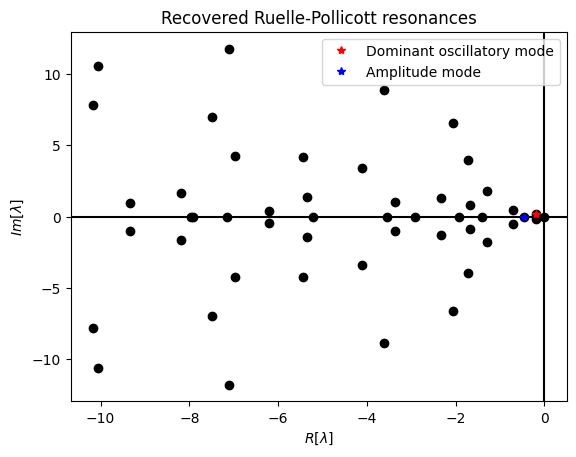

In [13]:
# THIS CELL ALLOWS TO VISUALIZE THE RESULTS WITHOUT RERUNNNING EDMD

def load_edmd_RBF_functions(path):
    """Load saved EDMD data and return PsiFunc and SigmaFunc."""
    data = np.load(path)
    centers = data["centers"]
    lambdas      = data["lambdas"]
    evecs  = data["evecs"]

    q1, qSigma = select(lambdas, evecs)

    # Basis functions
    F = build_F_RBFs(centers)
    dF = build_dF_RBFs(centers)

    def PsiFunc(X):
        Q1 = q1.T @ F(X)
        return np.mod(np.angle(Q1), 2 * np.pi)

    def SigmaFunc(X):
        return qSigma.T @ F(X)
    
    def gradPsiFunc(X):
        Q = q1.T @ F(X)

        # ∂Q*/∂x_k = q1^T @ dF[:,k,:]  for k=0 (x) and k=1 (y)
        grad_Q = np.einsum('i,ijk->jk', q1, dF(X))        # (2, N), complex
    
        Re_Q = np.real(Q)                          # (N,)
        Im_Q = np.imag(Q)                          # (N,)
        grad_Re_Q = np.real(grad_Q)                     # (2, N)
        grad_Im_Q = np.imag(grad_Q)                     # (2, N)
    
        # arctan quotient rule: (Re·∇Im - Im·∇Re) / (Re² + Im²)
        denom = Re_Q**2 + Im_Q**2                   # (N,)
        grad_psi = (Re_Q * grad_Im_Q - Im_Q * grad_Re_Q) / denom  # (2, N)

        return grad_psi

    return PsiFunc, SigmaFunc, gradPsiFunc

# Saving and visualizing
save_path = './HR_RBF_func.npz'
PsiFunc, SigmaFunc, gradPsiFunc = load_edmd_RBF_functions(save_path)

(-0.18051659639250306+0.1843081033479994j) -0.4508726912815262


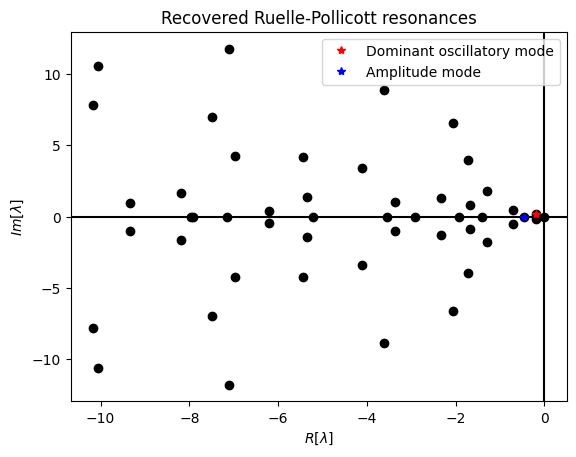

/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:17: RuntimeWarning: divide by zero encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:17: RuntimeWarning: overflow encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:17: RuntimeWarning: invalid value encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:21: RuntimeWarning: divide by zero encountered in matmul
  return qSigma.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:21: RuntimeWarning: overflow encountered in matmul
  return qSigma.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:21: RuntimeWarning: invalid value encountered in matmul
  return qSigma.T @ F(X)


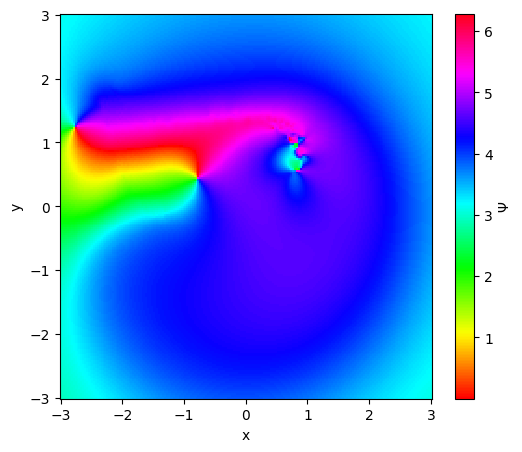

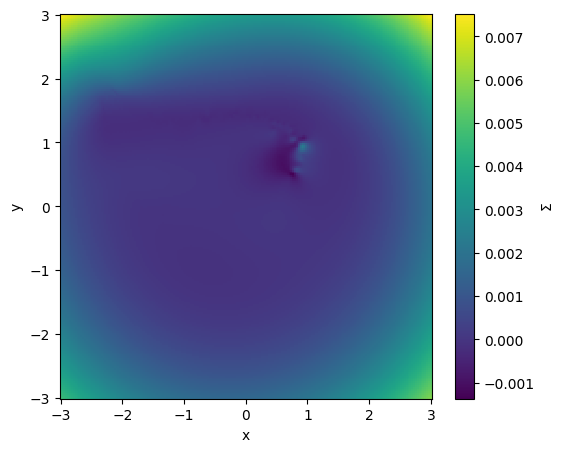

In [14]:
def visualize_grid(path):
    
    PsiFunc, SigmaFunc, _ = load_edmd_RBF_functions(path)

    # Visualize in 2D space: build a grid
    gridSize = 200
    x, y = 2*[np.linspace(-3, 3, gridSize)]
    X, Y = np.meshgrid(x, y)
    XFlat = X.flatten()
    YFlat = Y.flatten()
    flatgrid = np.vstack((XFlat, YFlat))
    
    # Get the functions on the grid
    Psi = PsiFunc(flatgrid).reshape((gridSize, gridSize))
    Sigma = SigmaFunc(flatgrid).reshape((gridSize, gridSize))
    
    # Visualize phase
    plt.figure(figsize=(6, 5))
    plt.pcolormesh(X, Y, Psi, cmap='hsv')
    plt.colorbar(label=r'$\Psi$')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()
    
    # Visualize amplitude
    plt.figure(figsize=(6, 5))
    plt.pcolormesh(X, Y, Sigma, cmap='viridis')
    plt.colorbar(label=r'$\Sigma$')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()
    
    return

save_path = './HR_RBF_func.npz'
visualize_grid(save_path)

/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:17: RuntimeWarning: divide by zero encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:17: RuntimeWarning: overflow encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:17: RuntimeWarning: invalid value encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:21: RuntimeWarning: divide by zero encountered in matmul
  return qSigma.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:21: RuntimeWarning: overflow encountered in matmul
  return qSigma.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:21: RuntimeWarning: invalid value encountered in matmul
  return qSigma.T @ F(X)


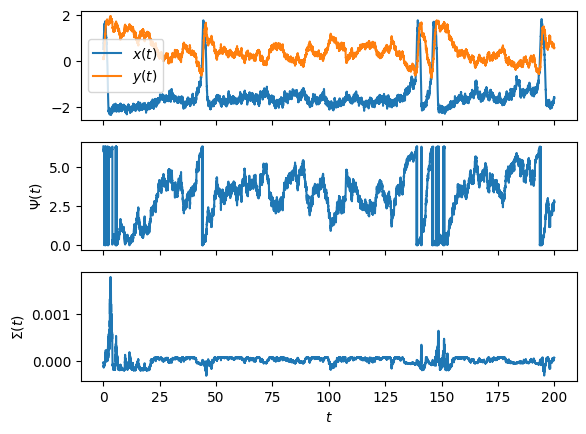

In [17]:
# Visualize applied to a new time series
X0 = np.random.rand(2)
T = 200
dt = 1e-2
nSteps = int(T/dt)
t = np.arange(0, T, dt)
XNew = HR(X0, PSto, nSteps, dt)

# Phase
Psi = PsiFunc(XNew)

# Shift phase so that it's 2pi at the max voltage (convention)
idx = np.argmax(XNew[0, :])
PsiMax = Psi[idx]
dPsi = 2 * np.pi - PsiMax
Psi = np.mod(Psi + dPsi, 2 * np.pi)

fig, axs = plt.subplots(3, sharex=True)

# Traj
axs[0].plot(t, XNew[0,:], label = r'$x(t)$')
axs[0].plot(t, XNew[1,:], label = r'$y(t)$')
axs[0].legend()

# Phase
axs[1].plot(t, Psi)
axs[1].set_ylabel(r'$\Psi(t)$')

# Last : amplitude
axs[2].plot(t, SigmaFunc(XNew))
axs[2].set_ylabel(r'$\Sigma(t)$')
axs[2].set_xlabel(r'$t$')
    
plt.show()

Now will use those recovered functions to make predictions about the behaviour of the system: expect average of the phase gradient on a given isochrone to give the average phase response of the system to an external, instaneous pulse. To make things easier, we will compute that average from a long realization of the system: bin the phase gradient values by the corresponding phase value and compute the mean of each bin such that

$iPRC(\psi) = \langle \boldsymbol \nabla \Psi(\mathbf x) \rangle_{\Psi(\mathbf x) = \psi}$.

This means we will need the derivatives of each $F_j$ to compute the PRC. They write:

$\partial_x F_j(\mathbf x) = \big[ 2 \ln (r+\epsilon_j) + \frac{r}{r+\epsilon_j}\big](x - (c_j)_x)$ 

with 

$r = \sqrt{x^2 + y^2}$

In [18]:
# Function to compute average gradient
def average_gradient(P, PsiFunc, grad_PsiFunc, n_phase_bins=60):
    
    # Take a very long time series
    X0 = np.random.rand(2)
    dt = 1e-3
    nSteps = 300000
    X = HR(X0, P, nSteps, dt=dt)
    
    # Take the phase and gradients
    Psi = PsiFunc(X)
    gradPsi = grad_PsiFunc(X)
    
    # Bin by phase
    bins = np.linspace(0, 2*np.pi, n_phase_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_idx     = np.clip(np.digitize(Psi, bins) - 1, 0, n_phase_bins - 1)

    # Average each spatial component per bin
    mean_grad = np.full((2, n_phase_bins), np.nan)
    for k in range(n_phase_bins):
        mask = bin_idx == k
        if mask.sum() > 0:
            mean_grad[:, k] = gradPsi[:, mask].mean(axis=1)

    return bin_centers, mean_grad

Let's compare this prediction to what we recover via direct perturbation of the system: kick the system at random phases and store the average phase shift caused by the pulse.

In [27]:
def empirical_iPRC(P, PsiFunc, n_pulses=500, dt=1e-3, tau=1e-1,
                   pulse_amp=0.1, pulse_dir=np.array([1.0, 0.0]),
                   n_phase_bins=50, n_steps_between=1000):
    """
    Empirical instantaneous Phase Response Curve via random delta pulses.

    P             : FHN parameters
    PsiFunc       : phase function from EDMD
    n_pulses      : number of perturbations to apply
    dt            : integration timestep
    tau           : subsampling time (for PsiFunc consistency)
    pulse_amp     : amplitude of delta kick
    pulse_dir     : (2,) direction of kick
    n_phase_bins  : number of bins in [0, 2π]
    n_steps_between: steps to run between pulses (stay on attractor)
    """
    #subSmplRate = int(tau / dt)

    phase_at_kick  = []
    phase_shifts   = []

    # Start in steady state
    X0 = np.random.rand(2)
    Xs = HR(X0, P, nSteps=10000, dt=dt)
    x  = Xs[:, -1]                    
    pert = pulse_amp * pulse_dir              # (2,)
    a, b, c, d, I, Dx, Dy = P
    dt_kick = 1e-6

    for _ in tqdm(range(n_pulses)):
        # Run freely to decorrelate, stay on unperturbed cycle
        Xs = HR(x, P, nSteps=n_steps_between, dt=dt)
        x  = Xs[:, -1]
    
        # Phase before kick
        psi_before = PsiFunc(x[:, None]).squeeze()
    
        # Shared noise for fair comparison
        dW = np.sqrt(dt_kick) * np.random.randn(2)
        fx = c*(x[0] - x[0]**3 / 3 - x[1] + I)
        fy = (x[0]**2 +d*x[0] - b*x[1] + a)/c
    
        # Unperturbed one-step
        x_ref  = np.array([x[0] + fx*dt_kick + np.sqrt(Dx)*dW[0],
                           x[1] + fy*dt_kick + np.sqrt(Dy)*dW[1]])
    
        # Perturbed one-step (same dW)
        x_kick = np.array([x[0] + fx*dt_kick + pert[0] + np.sqrt(Dx)*dW[0],
                           x[1] + fy*dt_kick + pert[1] + np.sqrt(Dy)*dW[1]])
    
        psi_ref  = PsiFunc(x_ref[:, None]).squeeze()
        psi_kick = PsiFunc(x_kick[:, None]).squeeze()
    
        delta_psi = np.angle(np.exp(1j * (psi_kick - psi_ref)))
    
        phase_at_kick.append(psi_before)
        phase_shifts.append(delta_psi)
    
        # Continue from UNPERTURBED state
        x = x_ref

    phase_at_kick = np.array(phase_at_kick)         # (n_pulses,)
    phase_shifts  = np.array(phase_shifts)          # (n_pulses,)

    # Bin and average
    bins       = np.linspace(0, 2 * np.pi, n_phase_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_idx    = np.digitize(phase_at_kick, bins) - 1
    bin_idx    = np.clip(bin_idx, 0, n_phase_bins - 1)

    iPRC    = np.zeros(n_phase_bins)
    iPRC_se = np.zeros(n_phase_bins)
    counts  = np.zeros(n_phase_bins, dtype=int)

    for idx, dPsi in zip(bin_idx, phase_shifts):
        iPRC[idx]  += dPsi
        counts[idx] += 1
    
    # Accumulate sum of squares for variance
    iPRC_ss = np.zeros(n_phase_bins)
    for idx, dPsi in zip(bin_idx, phase_shifts):
        iPRC_ss[idx] += dPsi**2
    
    mask = counts > 1
    iPRC[mask]    /= counts[mask]
    iPRC[~mask]    = np.nan
    
    # std = sqrt(E[x²] - E[x]²),  se = std / sqrt(n)
    variance       = np.zeros(n_phase_bins)
    variance[mask] = iPRC_ss[mask]/counts[mask] - iPRC[mask]**2
    iPRC_se[mask]  = np.sqrt(variance[mask] / counts[mask])
    iPRC_se[~mask] = np.nan

    return bin_centers, iPRC, iPRC_se
        

Now we can compare the prediction and the actual response:

In [17]:
# Empirical phase response
pulse_amp=0.05

print("Direct stimulation...")
bin_centers, iPRCx, iPRCx_se = empirical_iPRC(PSto, PsiFunc, n_pulses=30000, 
                                              n_phase_bins=60, pulse_amp=pulse_amp)

# Expected phase response
print("Average gradient...")
bin_centers_mean, mean_grad = average_gradient(PSto, PsiFunc, gradPsiFunc)

Python(95738) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Direct stimulation...


100%|████████████████████████████████████| 30000/30000 [00:35<00:00, 837.58it/s]


Average gradient...


/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_95469/631884000.py:13: RuntimeWarning: divide by zero encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_95469/631884000.py:13: RuntimeWarning: overflow encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_95469/631884000.py:13: RuntimeWarning: invalid value encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_95469/631884000.py:20: RuntimeWarning: divide by zero encountered in matmul
  Q = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_95469/631884000.py:20: RuntimeWarning: overflow encountered in matmul
  Q = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_95469/631884000.py:20: RuntimeWarning: invalid value encountered in matmul
  Q = q1.T @ F(X)


Plot the results

Plot the results

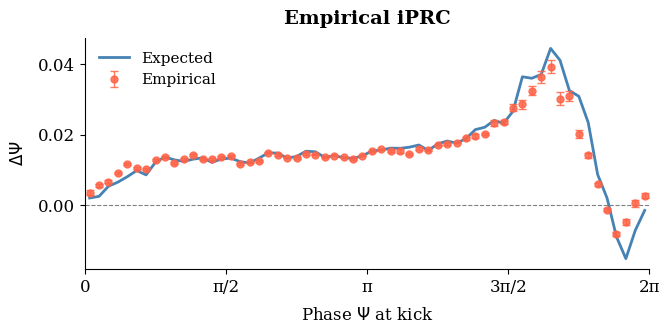

In [18]:
def plot_PRCs(bin_centers, iPRCx, iPRCx_se, bin_centers_mean, mean_grad):
    # ── Style ────────────────────────────────────────────────────────────────────
    mpl.rcParams.update({
        'font.family': 'serif',
        'font.size': 12,
        'axes.spines.top': False,
        'axes.spines.right': False,
    })
    
    fig, ax = plt.subplots(figsize=(7, 3.5))
    
    # Zero line
    ax.axhline(0, color='gray', lw=0.8, ls='--', zorder=0)
    
    # Expected
    ax.plot(bin_centers_mean, pulse_amp * mean_grad[0],
            color='steelblue', lw=2, label='Expected', zorder=2)
    
    # Empirical
    ax.errorbar(bin_centers, iPRCx, yerr=iPRCx_se,
                fmt='o', ms=5, color='tomato', ecolor='tomato',
                capsize=3, lw=1.5, elinewidth=1, alpha=0.85,
                label='Empirical', zorder=3)
    
    # Axes
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
    ax.set_xlabel(r'Phase $\Psi$ at kick', labelpad=8)
    ax.set_ylabel(r'$\Delta\Psi$', labelpad=8)
    ax.set_title('Empirical iPRC', fontsize=14, fontweight='bold', pad=10)
    
    ax.legend(frameon=False, fontsize=11)
    fig.tight_layout()
    plt.show()
    return

plot_PRCs(bin_centers, iPRCx, iPRCx_se, bin_centers_mean, mean_grad)

We obtain a function that captures the periodic component of the oscillation, and capture the temporal response of the system to an external perturbation. We will now apply to the system below bifurcation such that the oscillations are noise induced

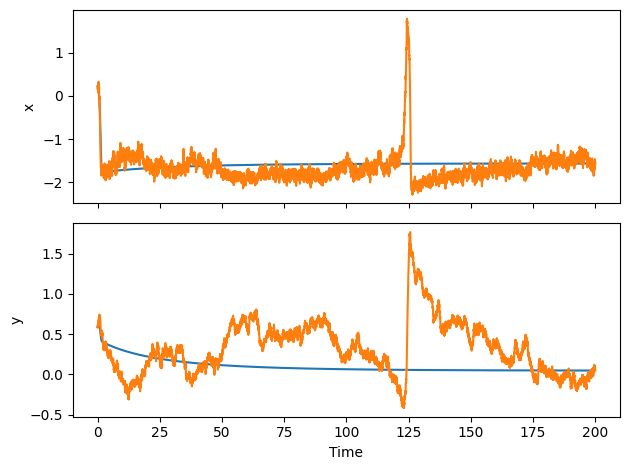

In [20]:
# Parameters
a, b, c, d, I, Dx, Dy = 0.42, 1.0, 3.0, 1.8, 0.34, 0.1, 0.01
PDet = (a, b, c, d, I, 0, 0)
PSto = (a, b, c, d, I, Dx, Dy)

# ICs
X0 = np.random.rand(2)

# Integration parameters
t_target = 200
dt = 1e-2
nSteps = int(t_target/dt)
ts = np.linspace(0, t_target, nSteps)

# Run
XsDet = HR(X0, PDet, nSteps, dt)
XsSto = HR(X0, PSto, nSteps, dt)

# Plot and compare
fig, axs = plt.subplots(2, sharex=True)

axs[0].plot(ts, XsDet[0,:])
axs[0].plot(ts, XsSto[0,:])
axs[0].set_ylabel('x')

axs[1].plot(ts, XsDet[1,:])
axs[1].plot(ts, XsSto[1,:])
axs[1].set_ylabel('y')

axs[1].set_xlabel('Time')
plt.tight_layout()
plt.show()

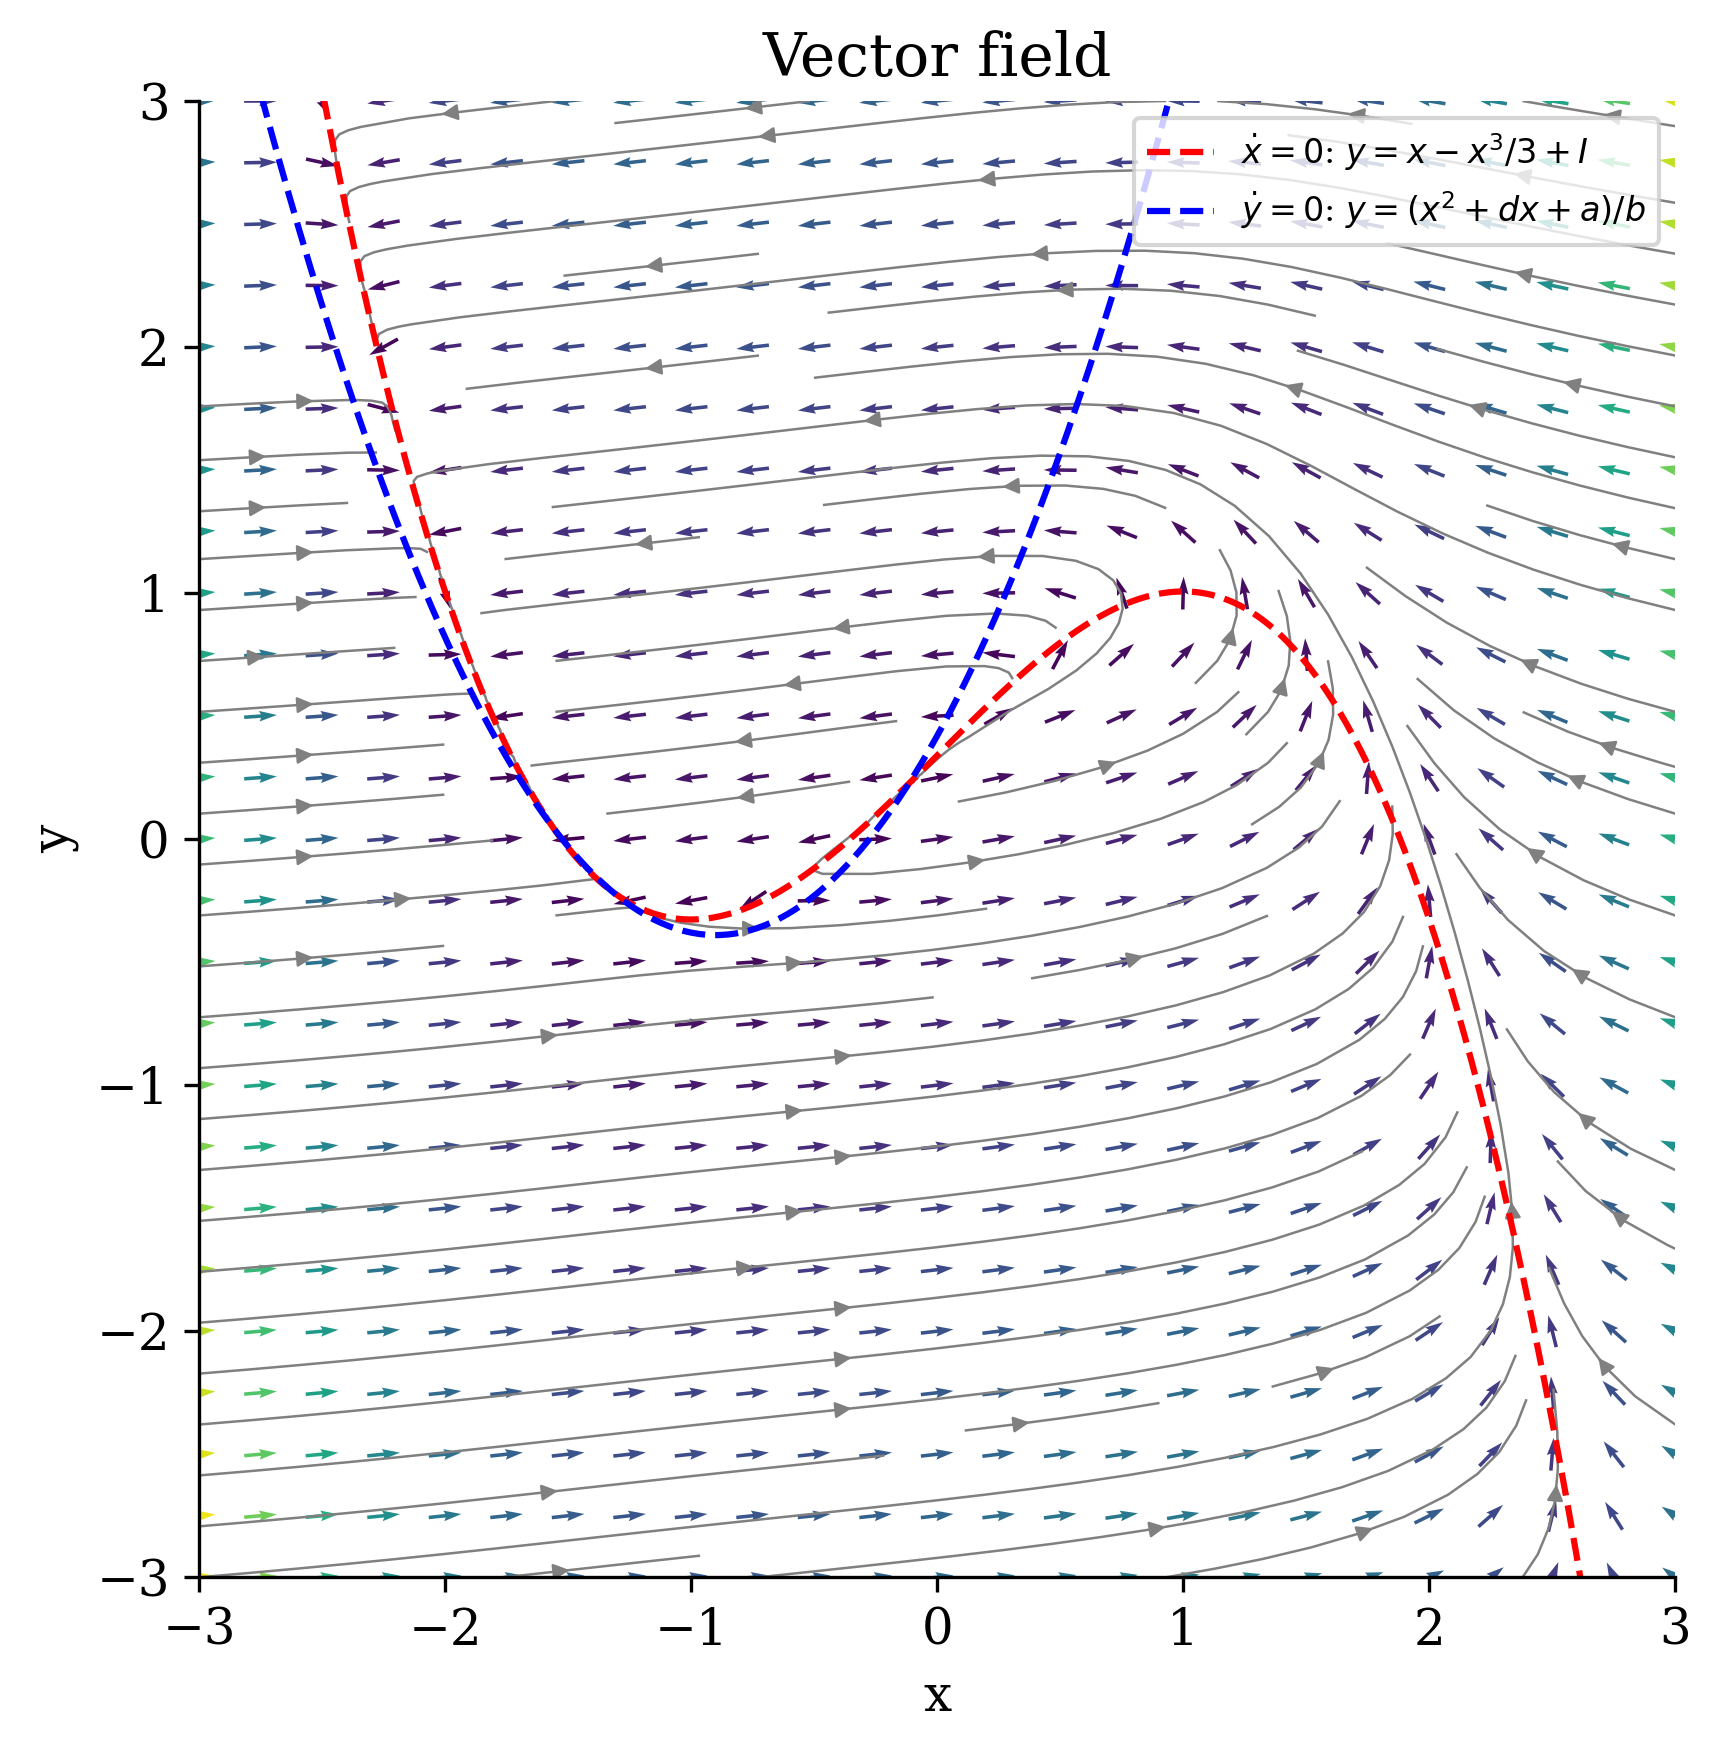

In [20]:
plot_vector_field(a , b , c, d, I)

Finding centers (may take some time)
Generating data
Running EDMD
Done
Runtime: 379.11s (6.32 min)
(-0.07779527648419968+0.08611215161121957j) -1.2572148201812023


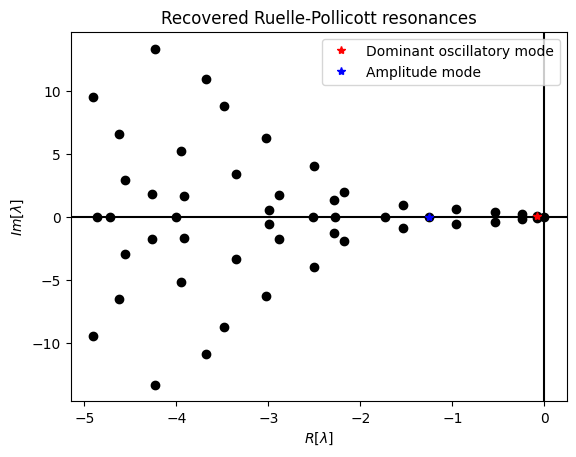

Saved EDMD functions to ./HR_below_RBF_func.npz


In [21]:
# THIS CELL RUNS EVERYTHING- SKIP IF YOU ALREADY HAVE THE RESULTS
# Integration parameters
t_target = 30
dt = 1e-2
nSteps = int(t_target/dt)
Xs = HR(X0, PSto, nSteps, dt)

# find centers for EDMD basis
print("Finding centers (may take some time)")
N_centers = 1000
centers = find_centers(Xs, N_centers, plot=False)
fRBF = build_F_RBFs(centers)

# How many data points + time step
nTarget = 1e6
tauTarget = 1e-1

lambdas, evecs, centers = runEDMD(PSto, fRBF, nTarget, tauTarget)
q1, qSigma = select(lambdas, evecs)

# Save the function ingredients 
save_path = './HR_below_RBF_func.npz'
np.savez(save_path,
         centers=centers,
         lambdas=lambdas,
         evecs=evecs)

print(f"Saved EDMD functions to {save_path}")

(-0.07779527648419968+0.08611215161121957j) -1.2572148201812023


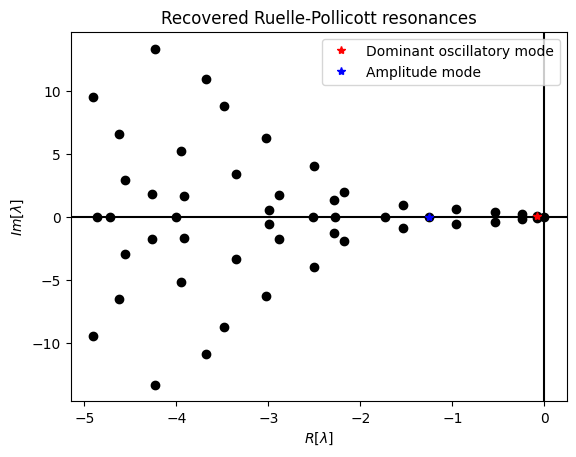

(-0.07779527648419968+0.08611215161121957j) -1.2572148201812023


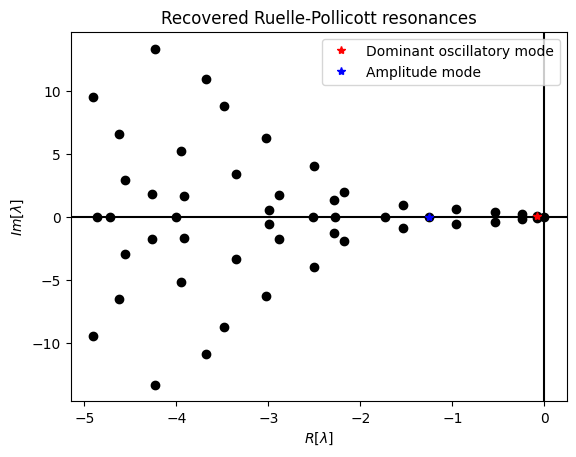

/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:17: RuntimeWarning: divide by zero encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:17: RuntimeWarning: overflow encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:17: RuntimeWarning: invalid value encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:21: RuntimeWarning: divide by zero encountered in matmul
  return qSigma.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:21: RuntimeWarning: overflow encountered in matmul
  return qSigma.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:21: RuntimeWarning: invalid value encountered in matmul
  return qSigma.T @ F(X)


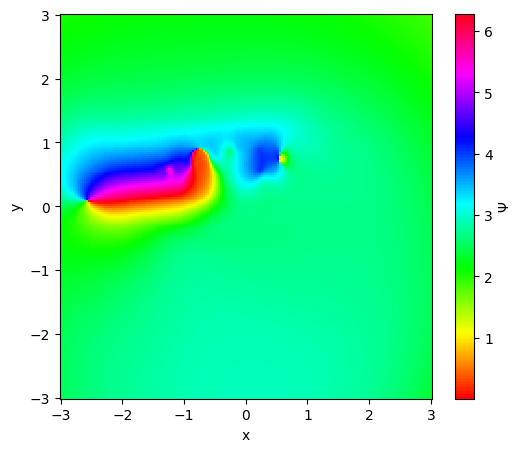

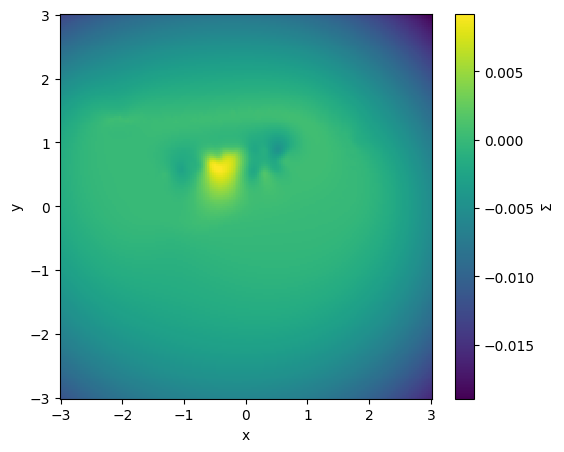

In [22]:
# THIS CELL ALLOWS USE STORED RESULTS WITHOUT RERUNNNING EDMD
save_path = './HR_below_RBF_func.npz'
PsiFunc, SigmaFunc, gradPsiFunc = load_edmd_RBF_functions(save_path)
visualize_grid(save_path)

(-0.07779527648419968+0.08611215161121957j) -1.2572148201812023


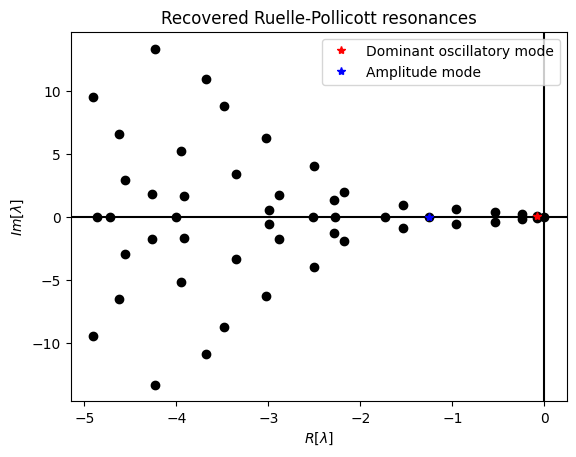

/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:17: RuntimeWarning: divide by zero encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:17: RuntimeWarning: overflow encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:17: RuntimeWarning: invalid value encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:21: RuntimeWarning: divide by zero encountered in matmul
  return qSigma.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:21: RuntimeWarning: overflow encountered in matmul
  return qSigma.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:21: RuntimeWarning: invalid value encountered in matmul
  return qSigma.T @ F(X)


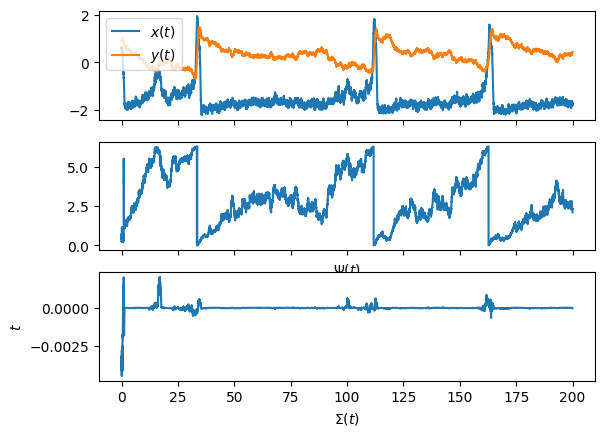

In [24]:
PsiFunc, SigmaFunc, gradPsiFunc = load_edmd_RBF_functions(save_path)
# Visualize applied to a new time series
X0 = np.random.rand(2)
T = 200
dt = 1e-2
nSteps = int(T/dt)
t = np.arange(0, T, dt)
XNew = HR(X0, PSto, nSteps, dt)

# Phase
Psi = PsiFunc(XNew)

# Shift phase so that it's 2pi at the max voltage (convention)
idx = np.argmax(XNew[0, :])
PsiMax = Psi[idx]
dPsi = 2 * np.pi - PsiMax
Psi = np.mod(Psi + dPsi, 2 * np.pi)


fig, axs = plt.subplots(3, sharex=True)

# Traj
axs[0].plot(t, XNew[0,:], label = r'$x(t)$')
axs[0].plot(t, XNew[1,:], label = r'$y(t)$')
axs[0].legend()

# Phase
axs[1].plot(t, Psi)
axs[1].set_xlabel(r'$\Psi(t)$')

# Last : amplitude
axs[2].plot(t, SigmaFunc(XNew))
axs[2].set_xlabel(r'$\Sigma(t)$')
axs[2].set_ylabel(r'$t$')
    
plt.show()

In [28]:
# Empirical phase response
pulse_amp=0.05

print("Direct stimulation...")
bin_centers, iPRCx, iPRCx_se = empirical_iPRC(PSto, PsiFunc, n_pulses=30000, 
                                              n_phase_bins=60, pulse_amp=pulse_amp)

# Expected phase response
print("Average gradient...")
bin_centers_mean, mean_grad = average_gradient(PSto, PsiFunc, gradPsiFunc)

# Visualize
plot_PRCs(bin_centers, iPRCx, iPRCx_se, bin_centers_mean, mean_grad)

Python(31145) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Direct stimulation...


100%|████████████████████████████████████| 30000/30000 [00:35<00:00, 840.98it/s]


Average gradient...


/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:17: RuntimeWarning: divide by zero encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:17: RuntimeWarning: overflow encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:17: RuntimeWarning: invalid value encountered in matmul
  Q1 = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:24: RuntimeWarning: divide by zero encountered in matmul
  Q = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:24: RuntimeWarning: overflow encountered in matmul
  Q = q1.T @ F(X)
/var/folders/bm/0qlwdsn11rj3dsc3s8g_wdkh0000gn/T/ipykernel_30597/2249840745.py:24: RuntimeWarning: invalid value encountered in matmul
  Q = q1.T @ F(X)


NameError: name 'plot_PRCs' is not defined